# <span style="color: #3498db;">3 Determinants 行列式</span>


## 3.1 Introduction to Determinants

### 2×2 行列式
对于 $ A = \begin{bmatrix} a & b \\ c & d \end{bmatrix} $，定义
$$
\det A = \begin{vmatrix} a & b \\ c & d \end{vmatrix} = ad - bc
$$

### 3×3 行列式
对于 $ A = \begin{bmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{bmatrix} $，有
$$
\det A = a_{11}a_{22}a_{33} + a_{12}a_{23}a_{31} + a_{13}a_{21}a_{32}
- a_{11}a_{23}a_{32} - a_{12}a_{21}a_{33} - a_{13}a_{22}a_{31}
$$

也可用对角线法则（Sarrus 法则）记忆，但**不适用于 4×4 及以上**。

### 余子式与代数余子式
- 删除 $ A $ 的第 $ i $ 行和第 $ j $ 列，得到的子矩阵记为 $ A_{ij} $。
- $(i,j)$ 余子式：$\det A_{ij}$
- $(i,j)$ 代数余子式：
$$
C_{ij} = (-1)^{i+j} \det A_{ij}
$$

### 余子式展开定理（定理 1）
行列式可沿任意一行或任意一列展开：
$$
\det A = \sum_{j=1}^n a_{ij} C_{ij} \quad (\text{沿第 } i \text{ 行})
$$
$$
\det A = \sum_{i=1}^n a_{ij} C_{ij} \quad (\text{沿第 } j \text{ 列})
$$

符号棋盘：
$$
\begin{bmatrix}
+ & - & + & \cdots \\
- & + & - & \cdots \\
+ & - & + & \cdots \\
\vdots & \vdots & \vdots & \ddots
\end{bmatrix}
$$

### 三角矩阵（定理 2）
若 $ A $ 是三角矩阵，则
$$
\det A = \prod_{i=1}^n a_{ii}
$$
即主对角线元素的乘积。




### 3.1 43
![3-1.png](picture/chapter_3_picture/3-1.png)

**题目**  
设 $\mathbf{u}=\begin{bmatrix}3\\0\end{bmatrix}$，$\mathbf{v}=\begin{bmatrix}1\\2\end{bmatrix}$。计算由 $\mathbf{u},\mathbf{v},\mathbf{u}+\mathbf{v},\mathbf{0}$ 确定的平行四边形面积，并计算 $\det[\mathbf{u}\ \mathbf{v}]$。比较两者。将 $\mathbf{v}$ 的第一个分量改为任意数 $x$，重复上述问题。画图并解释。

**解答**

由 $\mathbf{u},\mathbf{v}$ 确定的平行四边形面积为 $3 × 2=6$
$$
|\det[\mathbf{u}\ \mathbf{v}]| = \left|\begin{vmatrix}3&1\\0&2\end{vmatrix}\right| = |6| = 6.
$$
所以面积等于 $|\det[\mathbf{u}\ \mathbf{v}]|$。

将 $\mathbf{v}$ 改为 $\begin{bmatrix}x\\2\end{bmatrix}$，则
$$
[\mathbf{u}\ \mathbf{v}] = \begin{bmatrix}3&x\\0&2\end{bmatrix},\quad
\det = 6.
$$
面积仍为 6，与 $x$ 无关。因为 $\mathbf{u}$ 在 $x$ 轴上，$\mathbf{v}$ 的 $x$ 分量只影响水平位置，不改变以 $\mathbf{u}$ 为底的高（高恒为 2）。


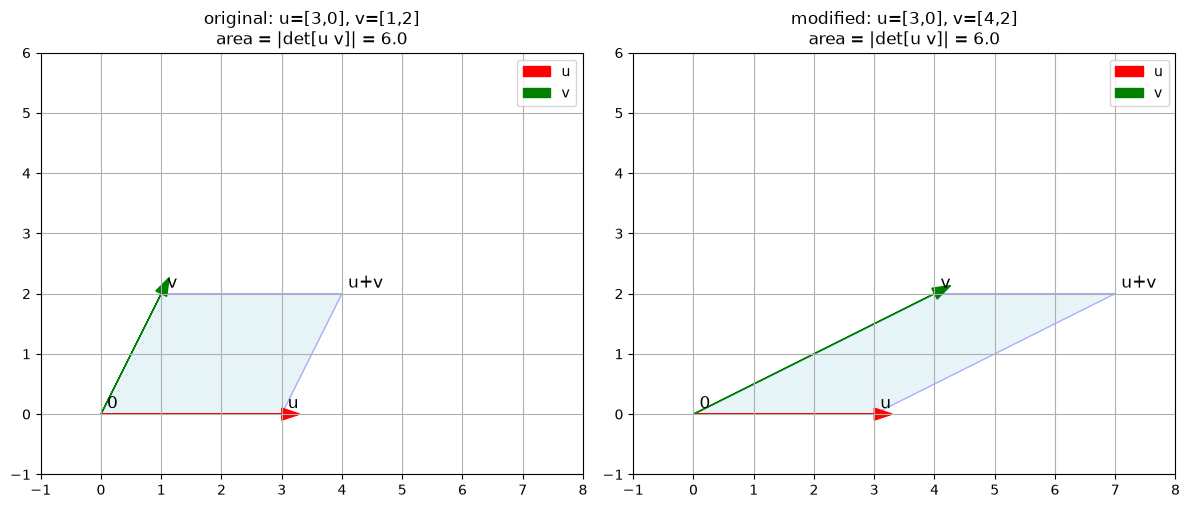

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def plot_parallelogram(ax, u, v, title):
    """在 ax 上绘制由 0, u, v, u+v 构成的平行四边形"""
    # 顶点：0, u, u+v, v
    pts = np.array([[0, 0], u, u + v, v])
    poly = Polygon(pts, closed=True, alpha=0.3, edgecolor='blue', facecolor='lightblue')
    ax.add_patch(poly)

    # 画向量箭头
    ax.arrow(0, 0, u[0], u[1], head_width=0.2, head_length=0.3, fc='red', ec='red', label='u')
    ax.arrow(0, 0, v[0], v[1], head_width=0.2, head_length=0.3, fc='green', ec='green', label='v')

    # 标出顶点
    for p, name in zip(pts, ['0', 'u', 'u+v', 'v']):
        ax.text(p[0] + 0.1, p[1] + 0.1, name, fontsize=12)

    # 计算面积并显示
    area = abs(np.linalg.det(np.column_stack((u, v))))
    ax.set_title(f"{title}\narea = |det[u v]| = {area}")
    ax.set_xlim(-1, max(8, u[0] + v[0] + 1))
    ax.set_ylim(-1, max(6, u[1] + v[1] + 1))
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()

# 原始 u, v
u = np.array([3, 0])
v1 = np.array([1, 2])
v2 = np.array([4, 2])   # 将 v 的第一个分量改为 4

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_parallelogram(axes[0], u, v1, "original: u=[3,0], v=[1,2]")
plot_parallelogram(axes[1], u, v2, "modified: u=[3,0], v=[4,2]")

plt.tight_layout()
plt.show()



### 3.1 44
![3-2.png](picture/chapter_3_picture/3-2.png)

**题目**  
设 $\mathbf{u}=\begin{bmatrix}a\\b\end{bmatrix}$，$\mathbf{v}=\begin{bmatrix}c\\0\end{bmatrix}$，其中 $a,b,c>0$。计算由 $\mathbf{u},\mathbf{v},\mathbf{u}+\mathbf{v},\mathbf{0}$ 确定的平行四边形面积，并计算 $\det[\mathbf{u}\ \mathbf{v}]$ 和 $\det[\mathbf{v}\ \mathbf{u}]$。画图并解释。

**解答**

平行四边形面积为底乘高，即有area=cb

$$
[\mathbf{u}\ \mathbf{v}] = \begin{bmatrix}a&c\\b&0\end{bmatrix},\quad
\det[\mathbf{u}\ \mathbf{v}] = a\cdot 0 - c\cdot b = -bc.
$$
$$
[\mathbf{v}\ \mathbf{u}] = \begin{bmatrix}c&a\\0&b\end{bmatrix},\quad
\det[\mathbf{v}\ \mathbf{u}] = c\cdot b - a\cdot 0 = bc.
$$
面积均为 $|\det| = bc$。交换两列行列式变号，但面积不变。


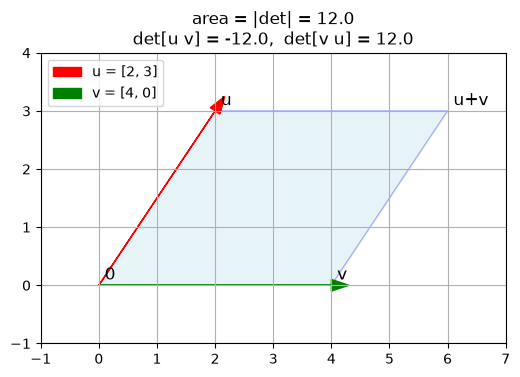

In [6]:
# 取 a, b, c > 0 的具体数值
a, b, c = 2, 3, 4
u = np.array([a, b])
v = np.array([c, 0])

# 平行四边形的四个顶点：0, u, u+v, v
pts = np.array([[0, 0], u, u + v, v])

fig, ax = plt.subplots(figsize=(6, 6))
poly = Polygon(pts, closed=True, alpha=0.3, edgecolor='blue', facecolor='lightblue')
ax.add_patch(poly)

# 画两个边向量
ax.arrow(0, 0, u[0], u[1], head_width=0.2, head_length=0.3,
         fc='red', ec='red', label=f'u = [{a}, {b}]')
ax.arrow(0, 0, v[0], v[1], head_width=0.2, head_length=0.3,
         fc='green', ec='green', label=f'v = [{c}, 0]')

# 标注顶点
for p, name in zip(pts, ['0', 'u', 'u+v', 'v']):
    ax.text(p[0] + 0.1, p[1] + 0.1, name, fontsize=12)

# 计算两个行列式
det_uv = np.linalg.det(np.column_stack((u, v)))
det_vu = np.linalg.det(np.column_stack((v, u)))
area = abs(det_uv)

ax.set_title(
    f"area = |det| = {area:.1f}\n"
    f"det[u v] = {det_uv:.1f},  det[v u] = {det_vu:.1f}"
)
ax.set_xlim(-1, max(u[0], v[0], u[0] + v[0]) + 1)
ax.set_ylim(-1, max(u[1], v[1], u[1] + v[1]) + 1)
ax.set_aspect('equal')
ax.grid(True)
ax.legend()
plt.show()

### 3.1 47
![3-3.png](picture/chapter_3_picture/3-3.png)

**题目**  
构造一个 $4\times4$ 随机整数矩阵 $A$（元素在 $-9$ 到 $9$ 之间）。$\det A^{-1}$ 与 $\det A$ 有什么关系？对 $n=4,5,6$ 的随机整数矩阵进行实验，提出猜想。


**解答**

对非奇异矩阵（$\det A \neq 0$），猜想：
$$
\det(A^{-1}) = \frac{1}{\det A}.
$$

对奇异矩阵（$\det A = 0$）：
- $A$ 不可逆，$A^{-1}$ 不存在，因此 $\det(A^{-1})$ **无定义**。
- 行化简为阶梯形后，主元个数小于 $n$，存在自由变量，列向量线性相关。
- 所以 $\det A = 0$ 与不可逆是等价的。



In [10]:
#随机情况
np.random.seed(0)
for n in [4, 5, 6]:
    A = np.random.randint(-9, 10, size=(n, n))
    detA = np.linalg.det(A)
    if abs(detA) > 1e-12:
        detAinv = np.linalg.det(np.linalg.inv(A))
        print(f"n={n}, det(A)={detA:.6f}, det(A^{-1})={detAinv:.6f}, 1/det(A)={1/detA:.6f}")
    else:
        print(f"n={n}, 矩阵奇异，跳过")

n=4, det(A)=1584.000000, det(A^-1)=0.000631, 1/det(A)=0.000631
n=5, det(A)=-176696.000000, det(A^-1)=-0.000006, 1/det(A)=-0.000006
n=6, det(A)=-548612.000000, det(A^-1)=-0.000002, 1/det(A)=-0.000002


In [11]:
#直接构造奇异矩阵
import sympy as sp

A = sp.Matrix([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [1, 2, 3, 4],
    [9, 10, 11, 12]
])

print("A =")
sp.pprint(A)

detA = A.det()
print(f"\ndet A = {detA}")

if detA == 0:
    print("det A = 0，所以 A 不可逆，A^{-1} 不存在，det(A^{-1}) 无定义。")
    rref, pivots = A.rref()
    print("\n行最简形：")
    sp.pprint(rref)
    print(f"主元列索引: {pivots}")
    print(f"主元个数 = {len(pivots)}, 列数 = {A.cols}")
    print(f"自由变量个数 = {A.cols - len(pivots)}")
    print("因此列向量线性相关，det A = 0。")

A =
⎡1  2   3   4 ⎤
⎢             ⎥
⎢5  6   7   8 ⎥
⎢             ⎥
⎢1  2   3   4 ⎥
⎢             ⎥
⎣9  10  11  12⎦

det A = 0
det A = 0，所以 A 不可逆，A^{-1} 不存在，det(A^{-1}) 无定义。

行最简形：
⎡1  0  -1  -2⎤
⎢            ⎥
⎢0  1  2   3 ⎥
⎢            ⎥
⎢0  0  0   0 ⎥
⎢            ⎥
⎣0  0  0   0 ⎦
主元列索引: (0, 1)
主元个数 = 2, 列数 = 4
自由变量个数 = 2
因此列向量线性相关，det A = 0。



**结论**  
- 当 $\det A \neq 0$ 时，$\det(A^{-1}) = \dfrac{1}{\det A}$。  
- 当 $\det A = 0$ 时，$A$ 不可逆，$\det(A^{-1})$ 无定义；行化简后主元数 $< n$，存在自由变量，列向量线性相关。  
- 因此原猜想只对可逆矩阵成立，遇到奇异矩阵时需单独讨论。

### 3.1 48
![3-4.png](picture/chapter_3_picture/3-4.png)

**题目**  
$\det(AB) = (\det A)(\det B)$ 是否成立？生成随机 $5\times5$ 矩阵 $A,B$，计算 $\det(AB) - (\det A)(\det B)$。对另外三对 $n\times n$ 矩阵重复，报告结果。

**解答**  
该等式成立，差应为 0（数值误差内）。




In [12]:


np.random.seed(1)
for n in [2, 3, 4, 5]:
    A = np.random.randn(n, n)
    B = np.random.randn(n, n)
    diff = np.linalg.det(A @ B) - np.linalg.det(A) * np.linalg.det(B)
    print(f"n={n}, diff = {diff:.2e}")


n=2, diff = 8.88e-16
n=3, diff = 2.22e-16
n=4, diff = 8.88e-16
n=5, diff = 2.08e-15




### 3.1 49
![3-5.png](picture/chapter_3_picture/3-5.png)

**题目**  
$\det(A+B) = \det A + \det B$ 是否成立？用四对随机矩阵实验，提出猜想。

**解答**  
一般不成立。



In [13]:

import numpy as np

np.random.seed(2)
for i in range(4):
    n = 3
    A = np.random.randn(n, n)
    B = np.random.randn(n, n)
    lhs = np.linalg.det(A + B)
    rhs = np.linalg.det(A) + np.linalg.det(B)
    print(f"第{i+1}对: det(A+B)={lhs:.4f}, det(A)+det(B)={rhs:.4f}, 差={lhs-rhs:.4f}")

第1对: det(A+B)=0.5016, det(A)+det(B)=1.4601, 差=-0.9586
第2对: det(A+B)=-6.4145, det(A)+det(B)=-4.5598, 差=-1.8547
第3对: det(A+B)=0.3404, det(A)+det(B)=0.6089, 差=-0.2685
第4对: det(A+B)=-1.6301, det(A)+det(B)=-1.2688, 差=-0.3613



### 3.1 50
![3-6.png](picture/chapter_3_picture/3-6.png)
**题目**  
构造随机 $4\times4$ 整数矩阵 $A$，比较 $\det A$ 与 $\det A^T$、$\det(-A)$、$\det(2A)$、$\det(10A)$。用另外两个随机 $4\times4$ 矩阵重复，提出猜想。再用 $5\times5$、$6\times6$ 验证。

**解答**  
猜想：
$$
\det A^T = \det A,\quad
\det(-A) = (-1)^n \det A,\quad
\det(kA) = k^n \det A.
$$
其中 $n$ 为矩阵阶数。



In [19]:
np.random.seed(2026)

def verify_det_properties(n, trials=3):
    """对 n 阶随机整数矩阵验证行列式性质"""
    print(f" n = {n} ")
    for t in range(trials):
        A = np.random.randint(-9, 10, size=(n, n))
        detA = np.linalg.det(A)
        detAT = np.linalg.det(A.T)
        det_minusA = np.linalg.det(-A)
        det_2A = np.linalg.det(2 * A)
        det_10A = np.linalg.det(10 * A)

        print(f"\n第 {t+1} 个矩阵：")
        print("A =")
        print(A)
        print(f"det(A)     = {detA:.6f}")
        print(f"det(A^T)   = {detAT:.6f}")
        print(f"det(-A)    = {det_minusA:.6f}")
        print(f"det(2A)    = {det_2A:.6f}")
        print(f"det(10A)   = {det_10A:.6f}")

        print("\n验证：")
        print(f"  det(A^T) == det(A) ? {np.isclose(detAT, detA)}")
        print(f"  det(-A) == (-1)^n det(A) ? {np.isclose(det_minusA, (-1)**n * detA)}")
        print(f"  det(2A) == 2^n det(A) ? {np.isclose(det_2A, 2**n * detA)}")
        print(f"  det(10A) == 10^n det(A) ? {np.isclose(det_10A, 10**n * detA)}")

        # 打印比例
        print(f"  det(-A)/det(A)   = {det_minusA/detA:.6f}  (期望 {(-1)**n})")
        print(f"  det(2A)/det(A)   = {det_2A/detA:.6f}  (期望 {2**n})")
        print(f"  det(10A)/det(A)  = {det_10A/detA:.6f}  (期望 {10**n})")

# 验证 n=4,5,6
for n in [4, 5, 6]:
    verify_det_properties(n, trials=3)
    print("\n" + "-"*70 + "\n")

 n = 4 

第 1 个矩阵：
A =
[[-8 -3  4  4]
 [-4  3 -7  4]
 [-9 -2 -9 -2]
 [ 6 -8  7 -3]]
det(A)     = 4451.000000
det(A^T)   = 4451.000000
det(-A)    = 4451.000000
det(2A)    = 71216.000000
det(10A)   = 44510000.000000

验证：
  det(A^T) == det(A) ? True
  det(-A) == (-1)^n det(A) ? True
  det(2A) == 2^n det(A) ? True
  det(10A) == 10^n det(A) ? True
  det(-A)/det(A)   = 1.000000  (期望 1)
  det(2A)/det(A)   = 16.000000  (期望 16)
  det(10A)/det(A)  = 10000.000000  (期望 10000)

第 2 个矩阵：
A =
[[-5  7  8  0]
 [ 6  6  0 -3]
 [-1 -9  6 -6]
 [-5 -8 -4  0]]
det(A)     = 3726.000000
det(A^T)   = 3726.000000
det(-A)    = 3726.000000
det(2A)    = 59616.000000
det(10A)   = 37260000.000000

验证：
  det(A^T) == det(A) ? True
  det(-A) == (-1)^n det(A) ? True
  det(2A) == 2^n det(A) ? True
  det(10A) == 10^n det(A) ? True
  det(-A)/det(A)   = 1.000000  (期望 1)
  det(2A)/det(A)   = 16.000000  (期望 16)
  det(10A)/det(A)  = 10000.000000  (期望 10000)

第 3 个矩阵：
A =
[[ 8 -7 -6 -6]
 [ 0 -3 -9  4]
 [-4  6  2  2]
 [ 3  5 -2 -9

### 3.1 51
![3-7.png](picture/chapter_3_picture/3-7.png)

**题目**  
回忆引言：$\det(D^T D)$ 越大，称重设计精度越高。对于四次称重四个物体，下列哪个矩阵对应最佳设计？描述最佳设计下每次称重应将 $s_1,s_2,s_3,s_4$ 放在左盘还是右盘。



**解答**  
最佳设计矩阵为ab矩阵（第一行全 $1$，其余行两两正交）：

计算得 $\det(D^T D) = 256$，是四阶中最大值。

称重规则：$+1$ 表示右盘，$-1$ 表示左盘。  
- 第1次：所有物体放左盘。  
- 第2次：$s_1,s_4$ 右盘，$s_2,s_3$ 左盘。  
- 第3次：$s_2,s_4$ 右盘，$s_1,s_3$ 左盘。  
- 第4次：$s_3,s_4$ 右盘，$s_1,s_2$ 左盘。


In [21]:
import numpy as np

D1 = np.array([
    [1, 1, 1, 1],
    [1, -1, 1, 1],
    [-1, -1, 1, -1],
    [1, 1, 1, -1]
])
D2 = np.array([
    [-1, -1, -1, -1],
    [1, -1, -1, 1],
    [-1, 1, -1, 1],
    [-1, -1, 1, 1]
])
D3 = np.array([
    [1, 1, -1, -1],
    [1, -1, -1, 1],
    [-1, 1, 1, -1],
    [-1, -1, 1, -1]
])
print("det(D1^T D1) =", np.linalg.det(D1.T @ D1))
print("det(D2^T D2) =", np.linalg.det(D2.T @ D2))
print("det(D3^T D3) =", np.linalg.det(D3.T @ D3))

det(D1^T D1) = 63.99999999999998
det(D2^T D2) = 255.99999999999994
det(D3^T D3) = 0.0


## 3.2 Properties of Determinants 行列式的性质

### 行变换对行列式的影响（定理 3）
设 $ A $ 为方阵：

| 行变换 | 对行列式的影响 |
|:---|:---|
| 行替换：$ R_i \leftarrow R_i + k R_j $ | 行列式不变 |
| 行交换：$ R_i \leftrightarrow R_j $ | 行列式变号 |
| 行倍乘：$ R_i \leftarrow k R_i $ | 行列式乘以 $ k $ |

> **列变换同理**（因为 $\det A^T = \det A$）。

### 用行化简计算行列式
将 $ A $ 化为阶梯形 $ U $：
- 只使用行替换：$\det A = \det U$
- 若进行了 $ r $ 次行交换：$\det A = (-1)^r \det U$
- 若 $ U $ 为三角矩阵，则 $\det U = \prod u_{ii}$

因此
$$
\det A = (-1)^r \prod_{i=1}^n u_{ii}
$$
其中 $ u_{ii} $ 是阶梯形的主元。

### 可逆性判据（定理 4）
$$
A \text{ 可逆} \iff \det A \neq 0
$$
若 $\det A = 0$，则 $ A $ 的列（或行）线性相关。

### 转置（定理 5）
$$
\det A^T = \det A
$$

### 乘积（定理 6）
$$
\det(AB) = (\det A)(\det B)
$$
**注意**：一般 $\det(A+B) \neq \det A + \det B$。

### 行列式的线性性质
固定其他列，行列式是某一列的线性函数：
$$
\det[\cdots, c\mathbf{x}, \cdots] = c \det[\cdots, \mathbf{x}, \cdots]
$$
$$
\det[\cdots, \mathbf{u}+\mathbf{v}, \cdots] = \det[\cdots, \mathbf{u}, \cdots] + \det[\cdots, \mathbf{v}, \cdots]
$$



### 3.2 37-42
![3-8.png](picture/chapter_3_picture/3-8.png)

### 3.2 37

**题目**  
证明：若 $A$ 可逆，则 $\det A^{-1} = \frac{1}{\det A}$。

**证明**  
由 $AA^{-1}=I$，取行列式：
$$
\det(AA^{-1}) = \det I = 1.
$$
又 $\det(AA^{-1}) = \det A \cdot \det A^{-1}$，所以
$$
\det A \cdot \det A^{-1} = 1.
$$
因 $A$ 可逆，$\det A \neq 0$，故
$$
\det A^{-1} = \frac{1}{\det A}.
$$



### 3.2 38

**题目**  
设 $A$ 为方阵，且 $\det A^3 = 0$。解释为什么 $A$ 不可逆。

**证明**  
由 $\det A^3 = (\det A)^3 = 0$，得 $\det A = 0$。  
由可逆性判据，$\det A = 0$ 意味着 $A$ 不可逆。



### 3.2 39

**题目**  
设 $A,B$ 为方阵。证明：即使 $AB \neq BA$，也总有 $\det AB = \det BA$。

**证明**  
由行列式乘积定理：
$$
\det AB = \det A \cdot \det B.
$$
同理
$$
\det BA = \det B \cdot \det A.
$$
由于标量乘法可交换，$\det A \cdot \det B = \det B \cdot \det A$，因此
$$
\det AB = \det BA.
$$



### 3.2 40

**题目**  
设 $A,P$ 为方阵，$P$ 可逆。证明 $\det(PAP^{-1}) = \det A$。

**证明**  
$$
\det(PAP^{-1}) = \det P \cdot \det A \cdot \det P^{-1}
= \det P \cdot \det A \cdot \frac{1}{\det P}
= \det A.
$$



### 3.2 41

**题目**  
设 $U$ 为方阵，且 $U^T U = I$。证明 $\det U = \pm 1$。

**证明**  
对 $U^T U = I$ 两边取行列式：
$$
\det(U^T U) = \det I = 1.
$$
由 $\det(U^T U) = \det U^T \cdot \det U = \det U \cdot \det U = (\det U)^2$，得
$$
(\det U)^2 = 1.
$$
所以
$$
\det U = \pm 1.
$$



### 3.2 42

**题目**  
求 $\det(rA)$ 的公式，其中 $A$ 为 $n\times n$ 矩阵。

**解答**  
矩阵 $rA$ 相当于将 $A$ 的每一行都乘以 $r$。每行乘以 $r$ 使行列式乘以 $r$，共有 $n$ 行，所以
$$
\det(rA) = r^n \det A.
$$



### 3.2 51-52
![3-9.png](picture/chapter_3_picture/3-9.png)
### 3.2 51

**题目**  
设 $A$ 为 $n\times n$ 矩阵，计算机给出 $\det A = 5$ 且 $\det(A^{-1}) = 1$。是否可信？为什么？

**解答**  
不可信。由 $\det(A^{-1}) = 1/\det A$，若 $\det A = 5$，则应有 $\det(A^{-1}) = 1/5 = 0.2$，而不是 1。



### 3.2 52

**题目**  
设 $A,B$ 为 $n\times n$ 矩阵，计算机给出 $\det A = 5$，$\det B = 2$，$\det AB = 7$。是否可信？为什么？

**解答**  
不可信。由 $\det(AB) = \det A \cdot \det B$，应有 $\det AB = 5 \times 2 = 10$，而不是 7。





### 3.2 53
![3-10.png](picture/chapter_3_picture/3-10.png)

**题目**  
对多个随机 $4\times5$ 和 $5\times6$ 矩阵，计算 $\det(A^T A)$ 和 $\det(A A^T)$。当 $A$ 的列数多于行数时，能得出什么结论？

**解答**  
当 $A$ 为 $m\times n$ 且 $n > m$（列多于行）时，$A^T A$ 是 $n\times n$ 矩阵，但其秩 $\operatorname{rank}(A^T A) = \operatorname{rank}(A) \le m < n$，所以 $A^T A$ 奇异，$\det(A^T A) = 0$。  
而 $A A^T$ 是 $m\times m$ 矩阵，可能可逆，其行列式通常非零。



In [ ]:
np.random.seed(4)
for shape in [(4,5), (5,6)]:
    A = np.random.randn(*shape)
    det_ATA = np.linalg.det(A.T @ A)
    det_AAT = np.linalg.det(A @ A.T)
    print(f"shape={shape}, det(A^T A)={det_ATA:.2e}, det(A A^T)={det_AAT:.2e}")

shape=(4, 5), det(A^T A)=8.85e-16, det(A A^T)=2.58e+01
shape=(5, 6), det(A^T A)=1.95e-13, det(A A^T)=1.19e+03




### 3.2 54
![3-11.png](picture/chapter_3_picture/3-11.png)

**题目**  
若 $\det A$ 接近零，是否 $A$ 接近奇异？用近奇异 $4\times4$ 矩阵实验，计算 $\det A$、$\det(10A)$、$\det(0.1A)$，并对比条件数。当 $A$ 为 $4\times4$ 单位矩阵时重复，讨论结果。

**解答**  
对比计算结果可知，$\det A$ 接近零不一定意味着矩阵接近奇异，因为行列式受缩放影响很大。条件数更能反映奇异性。


In [26]:
# 近奇异矩阵示例
A = np.array([
    [4,0,-7,-7],
    [-6,1,11,9],
    [7,-5,10,19],
    [-1,2,3,-1]
])
print("近奇异矩阵 A:")
print("det(A) =", np.linalg.det(A))
print("det(10A) =", np.linalg.det(10*A))
print("det(0.1A) =", np.linalg.det(0.1*A))
print("cond(A) =", np.linalg.cond(A))
print()

I = np.eye(4)
print("单位矩阵 I:")
print("det(I) =", np.linalg.det(I))
print("det(10I) =", np.linalg.det(10*I))
print("det(0.1I) =", np.linalg.det(0.1*I))
print("cond(I) =", np.linalg.cond(I))

近奇异矩阵 A:
det(A) = 1.000000000000334
det(10A) = 9999.99999999802
det(0.1A) = 0.00010000000000003135
cond(A) = 23682.92787471096

单位矩阵 I:
det(I) = 1.0
det(10I) = 10000.00000000001
det(0.1I) = 0.00010000000000000009
cond(I) = 1.0




## 3.3 Cramer's Rule, Volume, and Linear Transformations 克拉默法则，体积以及线性变换

### Cramer 法则（定理 7）
设 $ A $ 为可逆 $ n\times n $ 矩阵，$ \mathbf{b} \in \mathbb{R}^n $。  
方程 $ A\mathbf{x} = \mathbf{b} $ 的唯一解为
$$
x_i = \frac{\det A_i(\mathbf{b})}{\det A}, \quad i=1,\dots,n
$$
其中 $ A_i(\mathbf{b}) $ 是将 $ A $ 的第 $ i $ 列替换为 $ \mathbf{b} $ 得到的矩阵。






**例** 解方程组
$$
\begin{cases}
3x_1 - 2x_2 = 6 \\
-5x_1 + 4x_2 = 8
\end{cases}
$$
$$
A = \begin{bmatrix} 3 & -2 \\ -5 & 4 \end{bmatrix},\quad
\det A = 2
$$
$$
A_1(\mathbf{b}) = \begin{bmatrix} 6 & -2 \\ 8 & 4 \end{bmatrix},\quad
\det A_1 = 24 + 16 = 40
$$
$$
A_2(\mathbf{b}) = \begin{bmatrix} 3 & 6 \\ -5 & 8 \end{bmatrix},\quad
\det A_2 = 24 + 30 = 54
$$
所以
$$
x_1 = \frac{40}{2} = 20,\quad x_2 = \frac{54}{2} = 27
$$

### 伴随矩阵与逆矩阵（定理 8）
$$
A^{-1} = \frac{1}{\det A} \operatorname{adj} A
$$
其中 $\operatorname{adj} A$ 是伴随矩阵(adjugate or classical adjoint)：将代数余子式矩阵转置。


### 面积与体积（定理 9）
- 若 $ A $ 为 $ 2\times 2 $ 矩阵，则由 $ A $ 的列向量确定的平行四边形面积为 $ |\det A| $。
- 若 $ A $ 为 $ 3\times 3 $ 矩阵，则由 $ A $ 的列向量确定的平行六面体体积为 $ |\det A| $。


**如何去理解计算det是在计算有向面积/体积？**

从向量的角度更好理解，先看二维：

二元线性方程组：
$$
\begin{cases}
a_{11} x_1 + a_{12} x_2 = b_1 \\
a_{21} x_1 + a_{22} x_2 = b_2
\end{cases}
$$
增广矩阵：
$$
\begin{pmatrix}
a_{11} & a_{12} & b_1 \\
a_{21} & a_{22} & b_2
\end{pmatrix}
$$

向量形式
$$
\boldsymbol{\alpha}_1=\begin{pmatrix}a_{11}\\a_{21}\end{pmatrix},\quad
\boldsymbol{\alpha}_2=\begin{pmatrix}a_{12}\\a_{22}\end{pmatrix},\quad
\boldsymbol{\beta}=\begin{pmatrix}b_1\\b_2\end{pmatrix}
$$

> 想法：消元
> 寻找向量与$\boldsymbol{\alpha}_2$垂直 $\implies$ 化为 $\boldsymbol{\alpha}_1 x_1 + \boldsymbol{\alpha}_2 x_2 = \boldsymbol{\beta}$

取$\boldsymbol{r}\perp \boldsymbol{\alpha}_2$，两边同时和$\boldsymbol{r}$做内积：
$$
(\boldsymbol{\alpha}_1 x_1 + \boldsymbol{\alpha}_2 x_2)\cdot \boldsymbol{r} = \boldsymbol{\beta}\cdot \boldsymbol{r}
$$
$$
x_1 \boldsymbol{\alpha}_1\cdot \boldsymbol{r} = \boldsymbol{\beta}\cdot \boldsymbol{r}
$$

$\boldsymbol{\alpha}_1,\boldsymbol{\alpha}_2$不共线，$\boldsymbol{\alpha}_1\cdot \boldsymbol{r} \neq 0$：
$$
x_1=\frac{\boldsymbol{\beta}\cdot \boldsymbol{r}}{\boldsymbol{\alpha}_1\cdot \boldsymbol{r}}=\frac{a_{12}b_2 - a_{22}b_1}{a_{21}a_{12}-a_{11}a_{22}}
$$

定义二阶行列式
$$
\begin{vmatrix}
a_{11} & a_{12} \\
a_{21} & a_{22}
\end{vmatrix}
=\det(\boldsymbol{\alpha}_1,\boldsymbol{\alpha}_2)
= a_{11}a_{22}-a_{12}a_{21}
$$

于是克莱姆法则：
$$
x_1=\frac{
\begin{vmatrix}
b_1 & a_{12} \\
b_2 & a_{22}
\end{vmatrix}
}{
\begin{vmatrix}
a_{11} & a_{12} \\
a_{21} & a_{22}
\end{vmatrix}
},\qquad
x_2=\frac{
\begin{vmatrix}
a_{11} & b_1 \\
a_{21} & b_2
\end{vmatrix}
}{
\begin{vmatrix}
a_{11} & a_{12} \\
a_{21} & a_{22}
\end{vmatrix}
}
$$

$$x_1 \boldsymbol{\alpha}_1 + x_2 \boldsymbol{\alpha}_2 = \boldsymbol{\beta}$$

$$
\boldsymbol{\alpha}_1=\begin{pmatrix}a_{11}\\a_{21}\end{pmatrix},\quad
\boldsymbol{\alpha}_2=\begin{pmatrix}a_{12}\\a_{22}\end{pmatrix}
$$

二阶行列式
$$
\det(\boldsymbol{\alpha}_1,\boldsymbol{\alpha}_2)
= a_{11}a_{22}-a_{21}a_{12}
= \begin{pmatrix}a_{21}\\ -a_{11}\end{pmatrix}\cdot \begin{pmatrix}a_{11}\\a_{22}\end{pmatrix}
$$
$$
=|\boldsymbol{\alpha}_1||\boldsymbol{r}|\cos\theta
=|\boldsymbol{\alpha}_1||\boldsymbol{\alpha}_2|\sin\left(\frac{\pi}{2}-\theta\right)
$$
相当于计算底乘高，${\alpha}_2$为底，然后计算${\alpha}_1$到高方向的投影，就是在算面积。
![3-12.png](picture/chapter_3_picture/3-12.png)
$$
x_1=\frac{\det(\boldsymbol{\beta},\boldsymbol{\alpha}_2)}{\det(\boldsymbol{\alpha}_1,\boldsymbol{\alpha}_2)}
$$



## 推广：三元线性方程组
$$
\begin{cases}
a_{11}x_1 + a_{12}x_2 + a_{13}x_3 = b_1 \\
a_{21}x_1 + a_{22}x_2 + a_{23}x_3 = b_2 \\
a_{31}x_1 + a_{32}x_2 + a_{33}x_3 = b_3
\end{cases}
$$

令
$$
\boldsymbol{\alpha}_1=\begin{pmatrix}a_{11}\\a_{21}\\a_{31}\end{pmatrix},\quad
\boldsymbol{\alpha}_2=\begin{pmatrix}a_{12}\\a_{22}\\a_{32}\end{pmatrix},\quad
\boldsymbol{\alpha}_3=\begin{pmatrix}a_{13}\\a_{23}\\a_{33}\end{pmatrix},\quad
\boldsymbol{\beta}=\begin{pmatrix}b_1\\b_2\\b_3\end{pmatrix}
$$

向量形式：
$$x_1\boldsymbol{\alpha}_1 + x_2\boldsymbol{\alpha}_2 + x_3\boldsymbol{\alpha}_3 = \boldsymbol{\beta}$$

找同时与$\boldsymbol{\alpha}_2,\boldsymbol{\alpha}_3$垂直的向量$\boldsymbol{r}$，取
$$\boldsymbol{r}=\boldsymbol{\alpha}_2\times \boldsymbol{\alpha}_3 \quad(\boldsymbol{\alpha}_2,\boldsymbol{\alpha}_3\text{不共线})$$

两边同时点乘$\boldsymbol{r}$：
$$
x_1 \boldsymbol{\alpha}_1\cdot(\boldsymbol{\alpha}_2\times \boldsymbol{\alpha}_3)
= \boldsymbol{\beta}\cdot(\boldsymbol{\alpha}_2\times \boldsymbol{\alpha}_3)
$$

若 $\boldsymbol{\alpha}_1\cdot(\boldsymbol{\alpha}_2\times \boldsymbol{\alpha}_3)\neq0 \implies \boldsymbol{\alpha}_1,\boldsymbol{\alpha}_2,\boldsymbol{\alpha}_3$ 不共面
$$
x_1=\frac{\boldsymbol{\beta}\cdot(\boldsymbol{\alpha}_2\times \boldsymbol{\alpha}_3)}{\boldsymbol{\alpha}_1\cdot(\boldsymbol{\alpha}_2\times \boldsymbol{\alpha}_3)}
$$
> $\boldsymbol{\alpha}_1\cdot(\boldsymbol{\alpha}_2\times \boldsymbol{\alpha}_3)$：**混合积**

### 三阶行列式（几何含义：平行六面体的有向体积）
$$
\boldsymbol{\beta}\cdot(\boldsymbol{\alpha}_2\times \boldsymbol{\alpha}_3)
=\det(\boldsymbol{\beta},\boldsymbol{\alpha}_2,\boldsymbol{\alpha}_3)
=
\begin{vmatrix}
b_1 & a_{12} & a_{13}\\
b_2 & a_{22} & a_{23}\\
b_3 & a_{32} & a_{33}
\end{vmatrix}
$$

$$
\boldsymbol{\alpha}_1\cdot(\boldsymbol{\alpha}_2\times \boldsymbol{\alpha}_3)
=\pm \underbrace{|\boldsymbol{\alpha}_2\times \boldsymbol{\alpha}_3|}_{\text{底面面积}} \cdot |\boldsymbol{\alpha}_1|
$$

- $+$ 表示 $\boldsymbol{\alpha}_1,\boldsymbol{\alpha}_2,\boldsymbol{\alpha}_3$ 构成**右手系**
- $-$ 表示 $\boldsymbol{\alpha}_1,\boldsymbol{\alpha}_2,\boldsymbol{\alpha}_3$ 构成**左手系**
> 三阶行列式 = 平行六面体的**有向体积**




## 理解克拉默法则


### 1. 线性组合的观点

设 $A$ 是 $n\times n$ 可逆矩阵，记它的列向量为
$$
A = [\mathbf{a}_1 \ \mathbf{a}_2 \ \cdots \ \mathbf{a}_n].
$$
方程 $A\mathbf{x} = \mathbf{b}$ 等价于
$$
x_1\mathbf{a}_1 + x_2\mathbf{a}_2 + \cdots + x_n\mathbf{a}_n = \mathbf{b}.
$$
也就是说，$\mathbf{b}$ 是列向量 $\mathbf{a}_1,\dots,\mathbf{a}_n$ 的线性组合，系数就是 $x_1,\dots,x_n$。

克拉默法则告诉我们：
$$
x_i = \frac{\det A_i(\mathbf{b})}{\det A},
$$
其中 $A_i(\mathbf{b})$ 是把 $A$ 的第 $i$ 列换成 $\mathbf{b}$ 得到的矩阵：
$$
A_i(\mathbf{b}) = [\mathbf{a}_1 \ \cdots \ \mathbf{b} \ \cdots \ \mathbf{a}_n].
$$

从向量角度看，这个公式是在比较两个“有向体积”。


### 3. 替换一列后的体积

矩阵 $A_i(\mathbf{b})$ 的行列式
$$
\det A_i(\mathbf{b}) = \det[\mathbf{a}_1 \ \cdots \ \mathbf{b} \ \cdots \ \mathbf{a}_n]
$$
表示把第 $i$ 条边从 $\mathbf{a}_i$ 换成 $\mathbf{b}$ 后，新的平行多面体的有向体积。

因为
$$
\mathbf{b} = x_1\mathbf{a}_1 + x_2\mathbf{a}_2 + \cdots + x_n\mathbf{a}_n,
$$
代入第 $i$ 列：
$$
\det A_i(\mathbf{b}) 
= \det[\mathbf{a}_1 \ \cdots \ x_1\mathbf{a}_1 + \cdots + x_n\mathbf{a}_n \ \cdots \ \mathbf{a}_n].
$$

---

### 4. 利用行列式的多重线性性

行列式对每一列都是线性的。把第 $i$ 列拆开：
$$
\begin{aligned}
\det A_i(\mathbf{b})
&= \sum_{j=1}^n x_j \det[\mathbf{a}_1 \ \cdots \ \mathbf{a}_j \ \cdots \ \mathbf{a}_n].
\end{aligned}
$$
注意：第 $i$ 列被替换成了 $\mathbf{a}_j$。

- 当 $j \neq i$ 时，第 $i$ 列变成了 $\mathbf{a}_j$，于是矩阵中有两列相同（第 $j$ 列和第 $i$ 列都是 $\mathbf{a}_j$），行列式为 0。
- 只有当 $j = i$ 时，第 $i$ 列仍然是 $\mathbf{a}_i$，矩阵就是原来的 $A$，行列式为 $\det A$。

因此
$$
\det A_i(\mathbf{b}) = x_i \det A.
$$
于是
$$
x_i = \frac{\det A_i(\mathbf{b})}{\det A}.
$$

这就是从向量角度对克拉默法则的推导：**系数 $x_i$ 等于两个有向体积之比**。


### 5. 二维几何直观

在 $\mathbb{R}^2$ 中，设
$$
A = [\mathbf{a}_1 \ \mathbf{a}_2], \quad \mathbf{b} = x_1\mathbf{a}_1 + x_2\mathbf{a}_2.
$$
- $\det A$ 是由 $\mathbf{a}_1,\mathbf{a}_2$ 张成的平行四边形的有向面积。
- $A_1(\mathbf{b}) = [\mathbf{b} \ \mathbf{a}_2]$，它的行列式是由 $\mathbf{b}$ 和 $\mathbf{a}_2$ 张成的平行四边形的有向面积。

因为 $\mathbf{b}$ 在 $\mathbf{a}_1$ 方向上的“分量”是 $x_1\mathbf{a}_1$，所以由 $\mathbf{b}$ 和 $\mathbf{a}_2$ 张成的面积，正好是由 $x_1\mathbf{a}_1$ 和 $\mathbf{a}_2$ 张成的面积，即 $x_1 \det A$。因此
$$
x_1 = \frac{\det A_1(\mathbf{b})}{\det A}.
$$
同理，
$$
x_2 = \frac{\det A_2(\mathbf{b})}{\det A}.
$$

几何上，$x_i$ 就是“替换后体积”与“原体积”的比值。


### 总结

- 从向量角度看，$A\mathbf{x}=\mathbf{b}$ 表示 $\mathbf{b}$ 是列向量 $\mathbf{a}_1,\dots,\mathbf{a}_n$ 的线性组合。
- 行列式是这些列向量张成的有向体积。
- 把第 $i$ 列换成 $\mathbf{b}$，体积变成 $x_i$ 倍的原体积。
- 因此 $x_i = \dfrac{\det A_i(\mathbf{b})}{\det A}$。

克拉默法则本质上就是：**用有向体积之比来求线性组合的系数**。


### Linear Transformations

给定一个线性变换 $T:\mathbb{R}^2\to\mathbb{R}^2$（或 $\mathbb{R}^3\to\mathbb{R}^3$），它由矩阵 $A$ 确定：
$$
T(\mathbf{x}) = A\mathbf{x}.
$$
如果 $S$ 是平面（或空间）中的一个区域，那么 $T(S)$ 是它的像。  
**问题**：$T(S)$ 的面积（或体积）与 $S$ 的面积（或体积）有什么关系？

**答案（定理 10）**：
$$
\text{area}(T(S)) = |\det A| \cdot \text{area}(S),
$$
$$
\text{volume}(T(S)) = |\det A| \cdot \text{volume}(S).
$$
也就是说，**线性变换把面积/体积统一缩放 $|\det A|$ 倍**。



**定理 10**  
设 $T:\mathbb{R}^2\to\mathbb{R}^2$ 是由 $2\times2$ 矩阵 $A$ 确定的线性变换。若 $S$ 是 $\mathbb{R}^2$ 中的平行四边形，则
$$
\{\text{area of } T(S)\} = |\det A| \cdot \{\text{area of } S\}. \tag{5}
$$
若 $T$ 由 $3\times3$ 矩阵 $A$ 确定，$S$ 是 $\mathbb{R}^3$ 中的平行六面体，则
$$
\{\text{volume of } T(S)\} = |\det A| \cdot \{\text{volume of } S\}. \tag{6}
$$

**证明思路（二维情形）**

#### 第一步：平行四边形在原点

设 $S$ 是由向量 $\mathbf{b}_1,\mathbf{b}_2$ 张成的平行四边形：
$$
S = \{s_1\mathbf{b}_1 + s_2\mathbf{b}_2 : 0\le s_1\le 1,\ 0\le s_2\le 1\}.
$$
它的像为
$$
T(S) = \{s_1T(\mathbf{b}_1) + s_2T(\mathbf{b}_2) : 0\le s_1,s_2\le 1\}.
$$
因为 $T(\mathbf{b}_1)=A\mathbf{b}_1$，$T(\mathbf{b}_2)=A\mathbf{b}_2$，所以 $T(S)$ 是由向量 $A\mathbf{b}_1$ 和 $A\mathbf{b}_2$ 张成的平行四边形。

令 $B=[\mathbf{b}_1\ \mathbf{b}_2]$，则
$$
[A\mathbf{b}_1\ A\mathbf{b}_2] = AB.
$$
由定理 9（行列式的面积解释）和定理 6（乘积的行列式）：
$$
\text{area}(T(S)) = |\det(AB)| = |\det A|\,|\det B|
= |\det A| \cdot \text{area}(S).
$$

#### 第二步：任意平行四边形

任意平行四边形都可以写成 $\mathbf{p}+S$，其中 $S$ 是以原点为顶点的平行四边形。  
线性变换 $T$ 满足
$$
T(\mathbf{p}+S) = T(\mathbf{p}) + T(S),
$$
而平移不改变面积，所以
$$
\text{area}(T(\mathbf{p}+S)) = \text{area}(T(S))
= |\det A| \cdot \text{area}(S)
= |\det A| \cdot \text{area}(\mathbf{p}+S).
$$
因此公式对所有平行四边形成立。

**为什么绝对值 $|\det A|$ 而不是 $\det A$？**

- $\det A$ 可以是负数，表示**定向翻转**（比如反射）。
- 但几何上的面积/体积永远是**非负的**。
- 所以取绝对值 $|\det A|$ 表示纯粹的“缩放倍数”，忽略方向翻转。

例如：
- $\det A = 2$：面积扩大 2 倍，方向不变；
- $\det A = -2$：面积扩大 2 倍，方向反转（镜像）；
- $\det A = 0$：面积缩为 0（图形被压扁到低维）。

**推广到任意区域**

定理 10 最初只对平行四边形（或平行六面体）成立，但可以推广到任意有面积的区域。

**思路（二维）**：
1. 把区域 $R$ 用许多小正方形近似；
2. 每个小正方形在小线性变换下变成一个小平行四边形；
3. 每个小平行四边形的面积 = $|\det A| \times$ 小正方形面积；
4. 把所有小平行四边形的面积加起来，就得到 $T(R)$ 的近似面积；
5. 让网格越来越细，取极限，得到
$$
\text{area}(T(R)) = |\det A| \cdot \text{area}(R).
$$

三维情形完全类似，用小立方体近似。



**椭圆的面积**

**例 5** 求椭圆
$$
\frac{x_1^2}{a^2} + \frac{x_2^2}{b^2} = 1
$$
所围成的面积。

**解**：
单位圆盘 $D = \{(u_1,u_2): u_1^2 + u_2^2 \le 1\}$ 经线性变换
$$
A = \begin{bmatrix} a & 0 \\ 0 & b \end{bmatrix}
$$
变为椭圆。因为若 $\mathbf{x}=A\mathbf{u}$，则
$$
u_1 = \frac{x_1}{a},\quad u_2 = \frac{x_2}{b}.
$$
所以 $u_1^2+u_2^2\le 1$ 等价于 $\frac{x_1^2}{a^2}+\frac{x_2^2}{b^2}\le 1$。

由定理 10：
$$
\text{area(ellipse)} = |\det A| \cdot \text{area(unit disk)}
= ab \cdot \pi = \pi ab.
$$



**三维椭球体积**

类似地，单位球 $x_1^2+x_2^2+x_3^2\le 1$ 经
$$
A = \begin{bmatrix} a & 0 & 0 \\ 0 & b & 0 \\ 0 & 0 & c \end{bmatrix}
$$
变为椭球
$$
\frac{x_1^2}{a^2} + \frac{x_2^2}{b^2} + \frac{x_3^2}{c^2} \le 1.
$$
体积为
$$
|\det A| \cdot \frac{4\pi}{3} = abc \cdot \frac{4\pi}{3} = \frac{4}{3}\pi abc.
$$



**行列式为 0 时的几何意义**

若 $\det A = 0$，则
$$
\text{area}(T(S)) = 0.
$$
说明 $T$ 把二维区域压缩成一条线或一个点。  
例如投影矩阵
$$
A = \begin{bmatrix} 1 & 0 \\ 0 & 0 \end{bmatrix}
$$
把整个平面压到 $x$ 轴上，面积变为 0。  
这与“$\det A=0 \iff A$ 不可逆”一致。


###  这一节与其他章节的联系

| 章节 | 联系 |
|:---|:---|
| 1.9 线性变换 | 引入 $T(\mathbf{x})=A\mathbf{x}$ 的基本概念 |
| 3.2 行列式性质 | $\det(AB)=\det A\det B$ 是证明定理 10 的关键 |
| 3.3 定理 9 | 行列式的面积/体积解释 |
| 3.3 定理 10 | 线性变换对面积/体积的缩放 |


### 总结

- **行列式的绝对值** $|\det A|$ 是线性变换 $T(\mathbf{x})=A\mathbf{x}$ 对面积/体积的**统一缩放因子**。
- 不论区域形状如何，只要是 $T$ 的像，面积/体积都乘以同一个 $|\det A|$。
- 符号 $\det A$ 的正负反映**定向**是否翻转。
- $\det A = 0$ 意味着变换把区域压扁到低维，面积/体积变为 0。

> 线性变换会把整个空间均匀地拉伸/压缩/旋转/翻转，而 $|\det A|$ 就是它对“大小”的统一缩放倍数。



## 3.3 Exercises

### 3.3 23
![3-13.png](picture/chapter_3_picture/3-13.png)

**题目**  
求平行六面体体积，一个顶点在原点，相邻顶点在 $(1,0,-6)$、$(1,3,5)$、$(6,7,0)$。

**解答**  
体积为三个列向量构成矩阵的行列式绝对值：
$$
V = \left|\det\begin{bmatrix}
1&1&6\\
0&3&7\\
-6&5&0
\end{bmatrix}\right|.
$$
计算得
$$
\det = 1(3\cdot0 - 7\cdot5) - 1(0\cdot0 - 7\cdot(-6)) + 6(0\cdot5 - 3\cdot(-6))
= -35 - 42 + 108 = 31.
$$
所以体积为 $31$。



In [27]:
import numpy as np

M = np.array([
    [1, 1, 6],
    [0, 3, 7],
    [-6, 5, 0]
])
vol = abs(np.linalg.det(M))
print("体积 =", vol)

体积 = 31.0




### 3.3 25
![3-14.png](picture/chapter_3_picture/3-14.png)

**题目**  
用体积概念解释：$3\times3$ 矩阵 $A$ 的行列式为零当且仅当 $A$ 不可逆。不要引用定理 4。提示：考虑 $A$ 的列。

**解答**  
$A$ 的列向量确定一个平行六面体。  
- 若 $\det A = 0$，则体积为零，说明三个列向量共面（线性相关）。因此 $A$ 的列线性相关，$A$ 不可逆。  
- 反之，若 $A$ 不可逆，则列向量线性相关，它们共面或共线，平行六面体体积为零，所以 $\det A = 0$。





### 3.3 26
![3-15.png](picture/chapter_3_picture/3-15.png)

**题目**  
设 $T:\mathbb{R}^m\to\mathbb{R}^n$ 为线性变换，$\mathbf{p}$ 为向量，$S$ 为集合。证明 $\mathbf{p}+S$ 在 $T$ 下的像是平移集 $T(\mathbf{p})+T(S)$。

**证明**  
对任意 $\mathbf{x}\in \mathbf{p}+S$，存在 $\mathbf{s}\in S$ 使 $\mathbf{x}=\mathbf{p}+\mathbf{s}$。  
由 $T$ 线性，
$$
T(\mathbf{x}) = T(\mathbf{p}+\mathbf{s}) = T(\mathbf{p}) + T(\mathbf{s}).
$$
因此 $T(\mathbf{p}+S) \subseteq T(\mathbf{p})+T(S)$。  
反过来，对任意 $\mathbf{y}\in T(\mathbf{p})+T(S)$，存在 $\mathbf{s}\in S$ 使 $\mathbf{y}=T(\mathbf{p})+T(\mathbf{s})=T(\mathbf{p}+\mathbf{s})$，即 $\mathbf{y}\in T(\mathbf{p}+S)$。  
故
$$
T(\mathbf{p}+S) = T(\mathbf{p}) + T(S).
$$



### 3.3 31
![3-16.png](picture/chapter_3_picture/3-16.png)

**题目**  
设 $T:\mathbb{R}^3\to\mathbb{R}^3$ 由矩阵 $A=\begin{bmatrix}a&0&0\\0&b&0\\0&0&c\end{bmatrix}$ 确定，$a,b,c>0$。$S$ 为单位球 $x_1^2+x_2^2+x_3^2=1$。

a. 证明 $T(S)$ 的边界是椭球 $\frac{x_1^2}{a^2}+\frac{x_2^2}{b^2}+\frac{x_3^2}{c^2}=1$。  
b. 利用单位球体积 $4\pi/3$，求椭球体积。

**解答**

a. 设 $\mathbf{u}\in S$，则 $u_1^2+u_2^2+u_3^2=1$。  
令 $\mathbf{x}=A\mathbf{u}$，则 $x_1=au_1,\ x_2=bu_2,\ x_3=cu_3$，所以
$$
u_1=\frac{x_1}{a},\quad u_2=\frac{x_2}{b},\quad u_3=\frac{x_3}{c}.
$$
代入单位球方程得
$$
\frac{x_1^2}{a^2}+\frac{x_2^2}{b^2}+\frac{x_3^2}{c^2}=1.
$$
即 $T(S)$ 的边界为椭球。

b. 由定理 10，体积缩放因子为 $|\det A| = abc$。单位球体积为 $4\pi/3$，所以椭球体积为
$$
V = abc \cdot \frac{4\pi}{3} = \frac{4}{3}\pi abc.
$$





### 3.3 39
![3-17.png](picture/chapter_3_picture/3-17.png)
![3-18.png](picture/chapter_3_picture/3-18.png)


**解答**  
伴随矩阵 $\operatorname{adj} A$ 是代数余子式矩阵的转置。定理 8：$A^{-1}=\frac{1}{\det A}\operatorname{adj} A$。



In [29]:
import numpy as np

def minor(A, i, j):
    """返回删除第 i 行第 j 列后的子矩阵"""
    return np.delete(np.delete(A, i, axis=0), j, axis=1)

def cofactor(A, i, j):
    return (-1)**(i+j) * np.linalg.det(minor(A, i, j))

def adjugate(A):
    n = A.shape[0]
    C = np.zeros_like(A, dtype=float)
    for i in range(n):
        for j in range(n):
            C[i, j] = cofactor(A, i, j)
    return C.T

np.random.seed(0)  # 可复现
A = np.random.randn(4, 4)  # 随机4x4矩阵
detA = np.linalg.det(A)
adjA = adjugate(A)
B = adjA / detA
invA = np.linalg.inv(A)
diff = B - invA

np.set_printoptions(precision=16, suppress=False)
print("A =")
print(A)
print("\ndet(A) =", detA)
print("\nadj(A) =")
print(adjA)
print("\nB = adj(A)/det(A) =")
print(B)
print("\ninv(A) =")
print(invA)
print("\nB - inv(A) =")
print(diff)
print("\n最大绝对误差 =", np.max(np.abs(diff)))

A =
[[ 1.764052345967664   0.4001572083672233  0.9787379841057392
   2.240893199201458 ]
 [ 1.8675579901499675 -0.977277879876411   0.9500884175255894
  -0.1513572082976979]
 [-0.1032188517935578  0.4105985019383723  0.144043571160878
   1.454273506962975 ]
 [ 0.7610377251469934  0.1216750164928284  0.4438632327454257
   0.3336743273742668]]

det(A) = 0.2827659277931274

adj(A) =
[[ 0.5968768630599907 -0.169152250705986  -0.7762257913004699
  -0.7021670314585533]
 [ 0.0079782498034253 -0.2852912933724687 -0.1923883620953417
   0.6555074234266692]
 [-1.1406659436923585  0.3421821539953495  1.337652776644821
   1.9857365172889896]
 [ 0.1530927174392409  0.0346505226756494  0.0611706689299897
  -0.4315968194102336]]

B = adj(A)/det(A) =
[[ 2.1108514300798924 -0.5982059154939573 -2.74511783424048
  -2.4832094762572003]
 [ 0.0282150323615449 -1.0089309401562299 -0.6803802834268409
   2.318198053572568 ]
 [-4.03395823745382    1.2101251259865056  4.730600985361478
   7.022545229500782 ]
 [ 0


### 3.3 40
![3-19.png](picture/chapter_3_picture/3-19.png)
![3-20.png](picture/chapter_3_picture/3-20.png)

**题目**  
对随机 $4\times4$ 矩阵 $A$ 和随机 $4\times1$ 向量 $\mathbf{b}$ 测试 Cramer 法则。计算 $A\mathbf{x}=\mathbf{b}$ 的每个解分量，并与 $A^{-1}\mathbf{b}$ 比较。写出用 Cramer 法则产生 $\mathbf{x}$ 第二个分量的命令。

**解答**  
Cramer 法则：$x_i = \det A_i(\mathbf{b}) / \det A$，其中 $A_i(\mathbf{b})$ 是将 $A$ 的第 $i$ 列替换为 $\mathbf{b}$。

In [30]:
np.random.seed(6)
A = np.random.randn(4,4)
b = np.random.randn(4)

detA = np.linalg.det(A)
x_cramer = np.zeros(4)
for i in range(4):
    Ai = A.copy()
    Ai[:, i] = b
    x_cramer[i] = np.linalg.det(Ai) / detA

x_inv = np.linalg.solve(A, b)
print("Cramer 解:", x_cramer)
print("A^{-1}b 解:", x_inv)
print("第二个分量 (Cramer):", x_cramer[1])

Cramer 解: [0.1123452766596574 0.625214129232006  0.1757784893808002
 0.4258928049295241]
A^{-1}b 解: [0.1123452766596575 0.625214129232006  0.1757784893808003
 0.4258928049295241]
第二个分量 (Cramer): 0.625214129232006




### 3.3 41
![3-21.png](picture/chapter_3_picture/3-21.png)

**题目**  
如果 MATLAB 有 `flops` 命令，用它计算随机 $30\times30$ 矩阵求逆的浮点运算次数，并与形成 $(\operatorname{adj} A)/(\det A)$ 所需的浮点运算次数比较。

**解答**  
求逆通常使用高斯-约当消元，运算量约为 $2n^3$。  
而计算伴随矩阵需要计算 $n^2$ 个 $(n-1)\times(n-1)$ 行列式，每个行列式若用余子式展开需要约 $(n-1)!$ 次运算，总运算量巨大，远超求逆。


In [ ]:
import time

n = 30
np.random.seed(0)
A = np.random.randn(n, n)

# ---- 方法一：直接求逆 ----
start = time.perf_counter()
invA = np.linalg.inv(A)
time_inv = time.perf_counter() - start

# ---- 方法二：伴随矩阵除以行列式 ----
def cofactor_matrix(A):
    """构造伴随矩阵 adj(A) = C^T，其中 C 是代数余子式矩阵"""
    n = A.shape[0]
    adj = np.zeros_like(A, dtype=float)
    for i in range(n):
        for j in range(n):
            minor = np.delete(np.delete(A, i, axis=0), j, axis=1)
            sign = (-1) ** (i + j)
            # adj[j,i] = C_ij（伴随矩阵是转置）
            adj[j, i] = sign * np.linalg.det(minor)
    return adj

start = time.perf_counter()
detA = np.linalg.det(A)
adjA = cofactor_matrix(A)
B = adjA / detA
time_adj = time.perf_counter() - start

# ---- 结果 ----
print(f"方法一 inv(A) 耗时:        {time_inv:.6f} 秒")
print(f"方法二 adj(A)/det(A) 耗时: {time_adj:.6f} 秒")
print(f"耗时比值 (adj/inv):        {time_adj / time_inv:.1f} 倍")

# ---- 理论运算量估算 ----
print("\n理论浮点运算次数（flops）估算：")
print(f"  inv(A) 约需 (2/3)n^3   = {(2/3)*n**3:.2e} 次")
print(f"  adj(A)/det(A) 约需 (2/3)n^5 = {(2/3)*n**5:.2e} 次")
print(f"  比值约 n^2 = {n**2} 倍")

方法一 inv(A) 耗时:        0.000218 秒
方法二 adj(A)/det(A) 耗时: 0.017650 秒
耗时比值 (adj/inv):        81.0 倍

理论浮点运算次数（flops）估算：
  inv(A) 约需 (2/3)n^3   = 1.80e+04 次
  adj(A)/det(A) 约需 (2/3)n^5 = 1.62e+07 次
  比值约 n^2 = 900 倍




> 注：实际计算伴随矩阵的运算量远大于直接求逆，因此数值计算中不使用该方法。



## 总结对比

| 概念 | 公式/结论 |
|:---|:---|
| 2×2 行列式 | $ad - bc$ |
| 3×3 行列式 | 对角线法则或余子式展开 |
| 余子式展开 | 沿任意行/列，$ \sum a_{ij} C_{ij} $ |
| 三角矩阵 | $ \det = \prod a_{ii} $ |
| 行替换 | 行列式不变 |
| 行交换 | 行列式变号 |
| 行倍乘 | 行列式乘以 $k$ |
| 可逆性 | $A$ 可逆 $\iff \det A \neq 0$ |
| 转置 | $ \det A^T = \det A $ |
| 乘积 | $ \det(AB) = \det A \det B $ |
| Cramer 法则 | $ x_i = \frac{\det A_i(\mathbf{b})}{\det A} $ |
| 逆矩阵 | $ A^{-1} = \frac{1}{\det A} \operatorname{adj} A $ |
| 面积/体积|  $abs(\det A)$ 倍缩放 |
| 线性变换 | $ \text{area}(T(S)) = abs(\det A) \cdot \text{area}(S) $ |

> 行列式是本章核心，它连接了矩阵可逆性、线性方程组的解、以及几何上的面积/体积缩放。